In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import stress

In [39]:
df = pd.read_parquet("data/downstream2025.parquet")

In [40]:
gics_map = {
    10: 'Energy',
    15: 'Materials',
    20: 'Industrials',
    25: 'Consumer Discretionary',
    30: 'Consumer Staples',
    35: 'Health Care',
    40: 'Financials',
    45: 'Information Technology',
    50: 'Communication Services',
    55: 'Utilities',
    60: 'Real Estate',
}

df['gics_name'] = df['gics'].astype(int).map(gics_map)

In [41]:
df.head()

,date,csecid,returns,gics,mcap,gics_name
0,2025-01-01,70011129,0.0,20.0,4.482459e+06,Industrials
1,2025-01-01,70012234,0.0,20.0,2.270850e+06,Industrials
2,2025-01-01,70012564,0.0,25.0,1.907878e+07,Consumer Discretionary
3,2025-01-01,70021576,0.0,50.0,1.745045e+06,Communication Services
4,2025-01-01,70021617,0.0,55.0,5.365856e+07,Utilities


In [42]:
df_stress   = pd.read_parquet("value-30.parquet")
df_uncon    = pd.read_parquet("value-30_uncon.parquet")
df_gaussian = pd.read_parquet("value-30_Gaussian.parquet")
df_resample = pd.read_parquet("value-30_Resample.parquet")
df_stress.head()

,csecid,returns
0,70011129,-0.004488
1,70012234,0.001495
2,70012564,-0.021288
3,70021576,0.003076
4,70021617,-0.084697


In [ ]:
def get_stress_pv(df: pd.DataFrame, df_stress: pd.DataFrame,
                  horizon: int = 22, seed: int | None = None) -> pd.DataFrame:
    rng   = np.random.default_rng(seed)
    df    = df.dropna(subset=['mcap'])
    pools = {cid: g['returns'].to_numpy() for cid, g in df_stress.groupby('csecid')}

    out = {}
    for date, day in df.groupby('date'):
        w     = (day['mcap'] / day['mcap'].sum()).to_numpy()
        paths = np.stack([rng.choice(pools[c], horizon, replace=False)
                          for c in day['csecid']])
        port  = w @ paths
        out[date] = np.prod(1 + port) - 1

    return pd.Series(out, name='pv').rename_axis('date').reset_index()

In [ ]:
stress_pv   = get_stress_pv(df, df_stress,   seed=0)
uncon_pv    = get_stress_pv(df, df_uncon,    seed=0)
gaussian_pv = get_stress_pv(df, df_gaussian, seed=0)
resample_pv = get_stress_pv(df, df_resample, seed=0)
stress_pv.head()

In [ ]:
base = uncon_pv['pv'].mean()
for name, pv in [("stress", stress_pv), ("Gaussian", gaussian_pv), ("Resample", resample_pv)]:
    rel = (pv['pv'].mean() - base)
    print(f"{name:16s} diff of mean {rel * 100:+.2f}%, {base.mean()}, {pv['pv'].mean()}")

In [86]:
def sector_pv(df, df_stress, horizon=22, seed=None):
    rng   = np.random.default_rng(seed)
    df    = df.dropna(subset=['mcap'])
    pools = {cid: g['returns'].to_numpy() for cid, g in df_stress.groupby('csecid')}
    rows = []
    for date, day in df.groupby('date'):
        w     = (day['mcap'] / day['mcap'].sum()).to_numpy()
        paths = np.stack([rng.choice(pools[c], horizon, replace=False) for c in day['csecid']])
        for k, idx in day.groupby('gics_name').indices.items():
            rows.append((date, k, np.prod(1 + (w[idx] @ paths[idx])) - 1))
    return pd.DataFrame(rows, columns=['date', 'gics_name', 'pv'])

sec_s = sector_pv(df, df_stress, seed=0)
sec_u = sector_pv(df, df_uncon,  seed=0)
mean_s = sec_s.groupby('gics_name')['pv'].mean()
mean_u = sec_u.groupby('gics_name')['pv'].mean()

res_per_gics = [(v, (mean_s[v] - mean_u[v]) * 100)        # stress - uncon, 百分点
                for v in gics_map.values() if v in mean_s.index]
res_per_gics

[('Energy', np.float64(-0.16566359250140625)),
 ('Materials', np.float64(-0.049886136344513)),
 ('Industrials', np.float64(-0.01919358620778085)),
 ('Consumer Discretionary', np.float64(0.051916671054418745)),
 ('Consumer Staples', np.float64(0.1111224495478777)),
 ('Health Care', np.float64(0.10610814596209708)),
 ('Financials', np.float64(-0.20692967127138076)),
 ('Information Technology', np.float64(0.8579200761220238)),
 ('Communication Services', np.float64(0.23034565675377577)),
 ('Utilities', np.float64(0.0562691603395443)),
 ('Real Estate', np.float64(0.05960935901598166))]

In [93]:

sec_sum = sec_s.groupby('date')['pv'].sum().to_numpy()
total   = stress_pv.set_index('date')['pv'].to_numpy()
err     = sec_sum - total
print(f"max |sum_k sector_pv - stress_pv| = {np.abs(err).max():.2e}")
print(f"mean diff                         = {err.mean():+.2e}")
print(f"relative (vs mean stress_pv)      = {np.abs(err).mean() / total.mean():.2%}")

max |sum_k sector_pv - stress_pv| = 4.96e-02
mean diff                         = -8.11e-04
relative (vs mean stress_pv)      = 41.70%


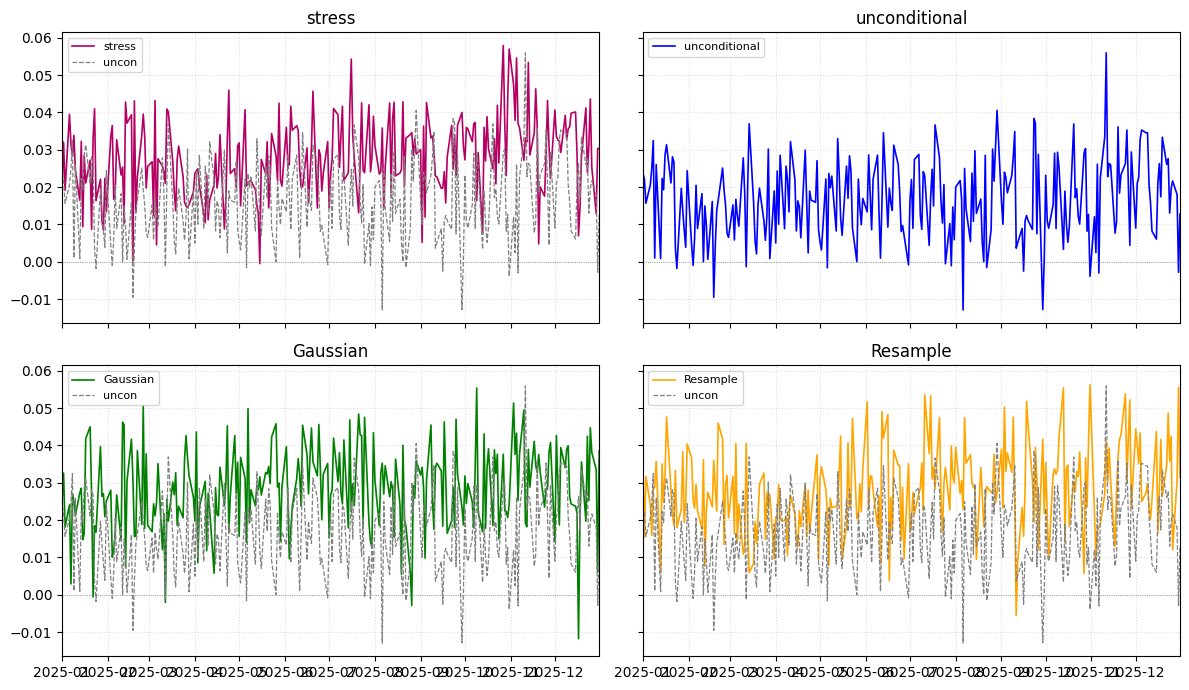

In [95]:
panels = [("stress", stress_pv,   "#B50063"),
          ("unconditional", uncon_pv,    "blue"),
          ("Gaussian",      gaussian_pv, "green"),
          ("Resample",      resample_pv, "orange")]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for ax, (name, pv, color) in zip(axes.ravel(), panels):
    ax.plot(pv['date'], pv['pv'], color=color, lw=1.2, label=name)
    if name != "unconditional":   # overlay uncon as reference
        ax.plot(uncon_pv['date'], uncon_pv['pv'], color="grey", lw=0.9, ls="--", label="uncon")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(name)
    ax.grid(True, ls=":", alpha=0.4)
    ax.legend(fontsize=8)
    ax.margins(x=0)
fig.tight_layout()
plt.show()

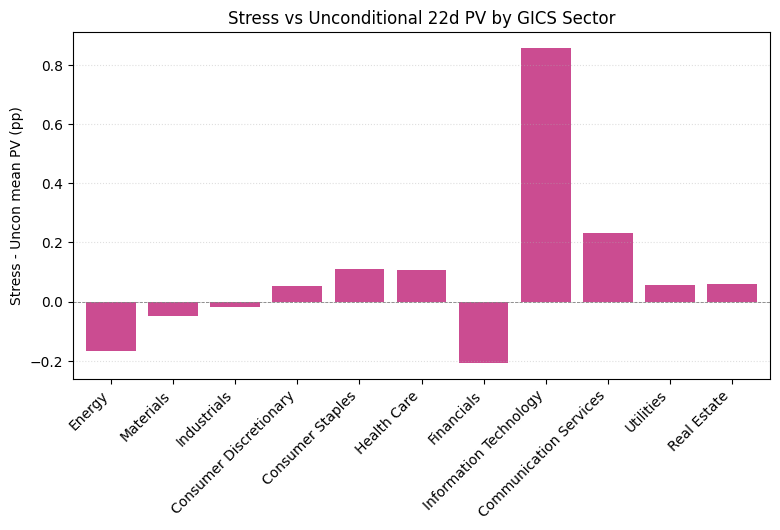

In [87]:
# bar plot
gics_names, delta_pvs = zip(*res_per_gics)
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(gics_names, delta_pvs, color="#B50063", alpha=0.7)
ax.set_ylabel("Stress - Uncon mean PV (pp)")
ax.set_title("Stress vs Unconditional 22d PV by GICS Sector")
ax.axhline(0, color="grey", lw=0.6, ls="--")
ax.grid(True, ls=":", alpha=0.4, axis='y')
ax.margins(x=0.02)
plt.xticks(rotation=45, ha='right')
plt.show()